## ****Data** ingestion**

In [0]:
# List the contents of your S3 bucket via Unity Catalog External Location
dbutils.fs.ls("s3://bdcc-amazon-reviews-2026/")

[FileInfo(path='s3://bdcc-amazon-reviews-2026/Video_Games.jsonl', name='Video_Games.jsonl', size=2682948518, modificationTime=1779333197000)]

In [0]:
df = spark.read.json("s3://bdcc-amazon-reviews-2026/Video_Games.jsonl")
df.printSchema()

root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



In [0]:
display(df.limit(5))

asin,helpful_vote,images,parent_asin,rating,text,timestamp,title,user_id,verified_purchase
B07DJWBYKP,0,List(),B07DK1H3H5,4.0,"I’m playing on ps5 and it’s interesting. It’s unique, massive, and has a neat story. People are freaking out angry about this game. I don’t think it’s a top 10 game but it’s definitely a good game on ps5 (played at launch).",1608186804795,It’s pretty sexual. Not my fav,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,true
B00ZS80PC2,1,List(),B07SRWRH5D,5.0,Nostalgic fun. A bit slow. I hope they don’t stretch it out too far. It’s good tho,1587051114941,Good. A bit slow,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,false
B01FEHJYUU,0,List(),B07MFMFW34,5.0,This was an order for my kids & they have really enjoyed playing this PC game.,1490877431000,... an order for my kids & they have really enjoyed playing this PC game,AGXVBIUFLFGMVLATYXHJYL4A5Q7Q,true
B07GXJHRVK,0,List(),B0BCHWZX95,5.0,"These work great, They use batteries which is a bummer, but for the 40 less that i paid its worth it. Batteries last a long time. Have been using to play rocket league on the switch with no issues",1577637634017,Great alt to pro controller,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,true
B00HUWA45W,0,List(),B00HUWA45W,5.0,"I would recommend to anyone looking to add just a little bit of height and a lot of grip to their thumb sticks. These will not create miracles, but it will give you better leverage for shooters.",1427591932000,solid product,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,true


In [0]:
from pyspark.sql.functions import col, approx_count_distinct

# Cardinality = how many DISTINCT values per column
# Skip 'images',it's a nested array-of-struct, cardinality isn't meaningful
columns_to_check = [c for c in df.columns if c != "images"]

cardinality = df.select([
    approx_count_distinct(col(c)).alias(c) for c in columns_to_check
])
display(cardinality)

asin,helpful_vote,parent_asin,rating,text,timestamp,title,user_id,verified_purchase
168080,774,132156,5,3740611,4584150,2508415,2616785,2


## **Data cleaning**

In [0]:
#checking missing values
from pyspark.sql.functions import col, count, when

null_counts = df.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df.columns
])
display(null_counts)

asin,helpful_vote,images,parent_asin,rating,text,timestamp,title,user_id,verified_purchase
0,0,0,0,0,0,0,0,0,0


In [0]:
# checking duplicates 
# We also need the total row count to interpret the duplicate counts
total = df.count()
print(f"Total rows: {total:,}\n")

# Definition 1: Exact full-row duplicates (every single column identical)
exact_dupes = total - df.dropDuplicates().count()
print(f"Exact full-row duplicates: {exact_dupes:,}")

# Definition 2: Same user reviewed same product more than once
user_product_dupes = total - df.dropDuplicates(["user_id", "asin"]).count()
print(f"Duplicate (user_id, asin) pairs: {user_product_dupes:,}")

# Definition 3: Same review text appearing more than once
text_dupes = total - df.dropDuplicates(["text"]).count()
print(f"Duplicate review texts: {text_dupes:,}")

Total rows: 4,624,615

Exact full-row duplicates: 53,646
Duplicate (user_id, asin) pairs: 53,650
Duplicate review texts: 577,491


In [0]:
# Drop exact full-row duplicates
df_dedup = df.dropDuplicates()

# Verify by counting before/after
new_count = df_dedup.count()
removed = 4_624_615 - new_count

print(f"Rows before dedup: 4,624,615")
print(f"Rows after dedup:  {new_count:,}")
print(f"Rows removed:      {removed:,}")

Rows before dedup: 4,624,615
Rows after dedup:  4,570,969
Rows removed:      53,646


In [0]:
from pyspark.sql.functions import length, col, count, when

# Add a 'text_length' column (a derived column on the deduplicated DataFrame)
df_with_length = df_dedup.withColumn("text_length", length("text"))

# 1. Statistical summary of review lengths (in characters)
print("Review length summary (characters):")
df_with_length.select("text_length").summary(
    "count", "mean", "stddev", "min", "5%", "25%", "50%", "75%", "95%", "max"
).show()

# 2. Single-pass count of reviews below common thresholds
print("\nHow many reviews fall below each threshold:")
thresholds = [1, 5, 10, 20, 50, 100]
counts_row = df_with_length.agg(*[
    count(when(col("text_length") < t, True)).alias(f"lt_{t}")
    for t in thresholds
]).collect()[0]

for t in thresholds:
    c = counts_row[f"lt_{t}"]
    print(f"  < {t:>3} chars: {c:>10,}  ({c/4_570_969*100:5.2f}%)")

Review length summary (characters):
+-------+------------------+
|summary|       text_length|
+-------+------------------+
|  count|           4570969|
|   mean|307.78768003020804|
| stddev| 648.4594813306339|
|    min|                 0|
|     5%|                10|
|    25%|                47|
|    50%|               129|
|    75%|               305|
|    95%|              1153|
|    max|             36893|
+-------+------------------+


How many reviews fall below each threshold:
  <   1 chars:        317  ( 0.01%)
  <   5 chars:     67,869  ( 1.48%)
  <  10 chars:    223,441  ( 4.89%)
  <  20 chars:    539,938  (11.81%)
  <  50 chars:  1,183,332  (25.89%)
  < 100 chars:  1,895,524  (41.47%)


In [0]:
from pyspark.sql.functions import col, length

# Keeping only reviews where text has 20 or more characters
df_clean = df_dedup.filter(length(col("text")) >= 20)

# Verify
after = df_clean.count()
print(f"Rows before length filter: 4,570,969")
print(f"Rows after length filter:  {after:,}")
print(f"Rows removed:              {4_570_969 - after:,}")
print(f"Retention rate:            {after/4_570_969*100:.2f}%")

Rows before length filter: 4,570,969
Rows after length filter:  4,031,031
Rows removed:              539,938
Retention rate:            88.19%


In [0]:
# Save the cleaned data to S3 as Parquet (Silver layer of the medallion architecture)
output_path = "s3://bdcc-amazon-reviews-2026/silver/video_games_cleaned/"

df_clean.write \
    .mode("overwrite") \
    .parquet(output_path)

print(f"Saved cleaned data to: {output_path}")

Saved cleaned data to: s3://bdcc-amazon-reviews-2026/silver/video_games_cleaned/


## **Data ingestion ( cleaned version)**

In [0]:
# Reload cleaned data from the silver layer (S3 Parquet)
df_clean = spark.read.parquet("s3://bdcc-amazon-reviews-2026/silver/video_games_cleaned/")

df_clean.printSchema()

root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



## **EDA**

In [0]:
print(f"Rows loaded: {df_clean.count():,}")

Rows loaded: 4,031,031


In [0]:
from pyspark.sql.functions import col, count, round as spark_round, mean

# Total rows (needed for percentages)
total = df_clean.count()
print(f"Analysing {total:,} reviews\n")

# 1. Overall mean rating
overall_mean = df_clean.select(mean("rating")).collect()[0][0]
print(f"Overall mean rating: {overall_mean:.3f} / 5.00\n")

# 2. Rating distribution
print("Rating distribution:")
rating_dist = df_clean.groupBy("rating") \
    .agg(count("*").alias("count")) \
    .withColumn("pct", spark_round(col("count") / total * 100, 2)) \
    .orderBy("rating")

display(rating_dist)

Analysing 4,031,031 reviews

Overall mean rating: 3.970 / 5.00

Rating distribution:


rating,count,pct
1.0,555507,13.78
2.0,241162,5.98
3.0,321277,7.97
4.0,563860,13.99
5.0,2349225,58.28


In [0]:
from pyspark.sql.functions import col, count, round as spark_round, mean

total = 4_031_031  

# One groupBy, three insights: count, percentage, mean rating per group
print("Verified vs unverified breakdown:")
verified_summary = df_clean.groupBy("verified_purchase") \
    .agg(
        count("*").alias("count"),
        spark_round(mean("rating"), 3).alias("mean_rating")
    ) \
    .withColumn("pct", spark_round(col("count") / total * 100, 2)) \
    .orderBy(col("verified_purchase").desc())

display(verified_summary)

Verified vs unverified breakdown:


verified_purchase,count,mean_rating,pct
true,3418620,4.017,84.81
false,612411,3.709,15.19


In [0]:
from pyspark.sql.functions import col, count, round as spark_round, from_unixtime, year, mean

total = 4_031_031

print("Reviews per year:")
reviews_per_year = df_clean \
    .withColumn("review_year", year(from_unixtime(col("timestamp") / 1000))) \
    .groupBy("review_year") \
    .agg(
        count("*").alias("count"),
        spark_round(mean("rating"), 3).alias("mean_rating")
    ) \
    .withColumn("pct", spark_round(col("count") / total * 100, 2)) \
    .orderBy("review_year")

display(reviews_per_year)

Reviews per year:


review_year,count,mean_rating,pct
1998,6,4.5,0.0
1999,447,4.114,0.01
2000,4762,4.102,0.12
2001,10725,4.023,0.27
2002,14161,4.032,0.35
2003,13937,3.977,0.35
2004,15081,3.908,0.37
2005,16435,3.837,0.41
2006,16287,3.783,0.4
2007,28376,3.98,0.7


In [0]:
from pyspark.sql.functions import col, from_unixtime, year

# Add 'review_year' column and filter to 2020+
df_recent = df_clean \
    .withColumn("review_year", year(from_unixtime(col("timestamp") / 1000))) \
    .filter(col("review_year") >= 2020)

# Verify
recent_count = df_recent.count()
print(f"Reviews from 2020-2023: {recent_count:,}")
df_recent.printSchema()

Reviews from 2020-2023: 1,414,664
root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- review_year: integer (nullable = true)



In [0]:
# 1) Draw a stratified sample from the 2020-2023 subset

sample_fraction = 300_000 / 1_414_664   # ≈ 0.212 (21.2%)

# Same fraction per rating class → proportional stratified sample
fractions = {1.0: sample_fraction, 2.0: sample_fraction, 3.0: sample_fraction,
             4.0: sample_fraction, 5.0: sample_fraction}

df_sample_spark = df_recent.sampleBy("rating", fractions=fractions, seed=42)

print(f"Sample size: {df_sample_spark.count():,}")
print("\nSample rating distribution (should mirror full data):")
df_sample_spark.groupBy("rating").count().orderBy("rating").show()


# 2) Bridge from Spark to Pandas

import pandas as pd

df_sample = df_sample_spark.toPandas()
print(f"\nPandas shape:  {df_sample.shape}")
print(f"Memory usage:  {df_sample.memory_usage(deep=True).sum() / (1024**2):.1f} MB")
df_sample.head(3)

Sample size: 300,882

Sample rating distribution (should mirror full data):
+------+------+
|rating| count|
+------+------+
|   1.0| 50588|
|   2.0| 19617|
|   3.0| 22451|
|   4.0| 33716|
|   5.0|174510|
+------+------+


Pandas shape:  (300882, 11)
Memory usage:  227.7 MB


,asin,helpful_vote,images,parent_asin,rating,text,timestamp,title,user_id,verified_purchase,review_year
0,B097TTFQH7,0,[],B097TTYVG3,3.0,Gets the job done. Not the best gaming mouse....,1650356721330,reliable gaming mouse,AGKUDV4SMU4OBP6IWAFE65SJOEIA,True,2022
1,B01IFJEWTM,0,[],B01IFJEWTM,2.0,What I disliked about the product is that for ...,1579107839984,Really?,AEZ5ZFXCVFBVIRB5WGWLDLYV3IAQ,True,2020
2,B07N85FY1G,0,[],B0BYVN9ZK2,5.0,Affordable and the sound quality is great.<br ...,1673297883836,"Very comfy, god sound quality.",AH4ZJANPZUHOCKLFYVXJKIPCY2JA,True,2023


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, publication-quality plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 5)

# Convert Unix milliseconds → proper datetime (for time-series charts)
df_sample["review_date"]  = pd.to_datetime(df_sample["timestamp"], unit="ms")
df_sample["review_month"] = df_sample["review_date"].dt.to_period("M")

# Add a text_length column (for histograms, scatter plots)
df_sample["text_length"] = df_sample["text"].str.len()

# Quick sanity check
print(f"Sample size: {len(df_sample):,} rows")
print(f"Date range:  {df_sample['review_date'].min().date()} → {df_sample['review_date'].max().date()}")
print(f"\nAll columns now available:")
print(df_sample.columns.tolist())

Sample size: 300,882 rows
Date range:  2020-01-01 → 2023-09-10

All columns now available:
['asin', 'helpful_vote', 'images', 'parent_asin', 'rating', 'text', 'timestamp', 'title', 'user_id', 'verified_purchase', 'review_year', 'review_date', 'review_month', 'text_length']


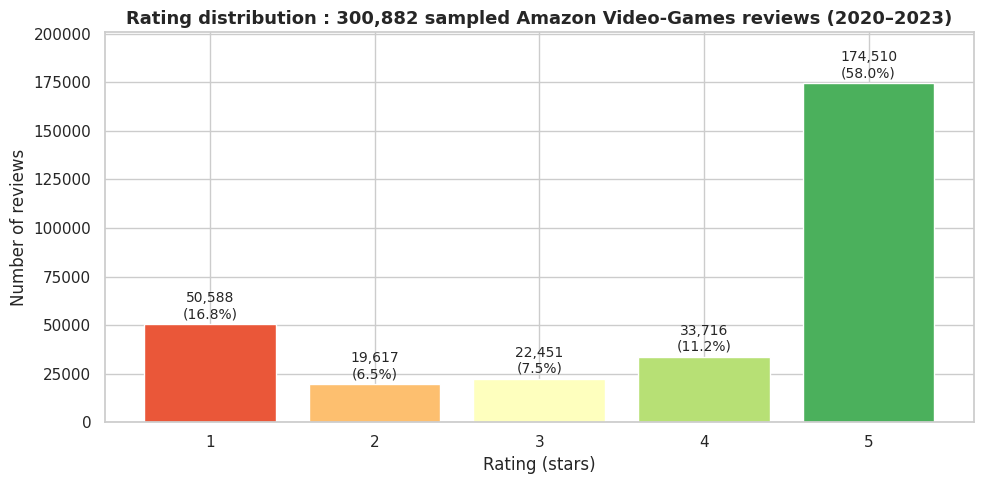

In [0]:
# Chart 1: Rating distribution as a coloured bar chart
rating_counts = df_sample["rating"].value_counts().sort_index()
total = len(df_sample)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=sns.color_palette("RdYlGn", n_colors=5))

# Add count + percentage labels on top of each bar
for bar, count in zip(bars, rating_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + total*0.005,
            f"{count:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10)

ax.set_xlabel("Rating (stars)", fontsize=12)
ax.set_ylabel("Number of reviews", fontsize=12)
ax.set_title(f"Rating distribution : {total:,} sampled Amazon Video-Games reviews (2020–2023)",
             fontsize=13, fontweight="bold")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(top=rating_counts.max() * 1.15)

plt.tight_layout()
plt.show()

## **Sentiment Analysis**

In [0]:
%pip install vaderSentiment

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Quick state check
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

print(f"VADER ready: {analyzer is not None}")
print(f"df_sample shape: {df_sample.shape}")
print(f"Columns: {df_sample.columns.tolist()}")

VADER ready: True
df_sample shape: (300882, 11)
Columns: ['asin', 'helpful_vote', 'images', 'parent_asin', 'rating', 'text', 'timestamp', 'title', 'user_id', 'verified_purchase', 'review_year']


In [0]:
import time

start = time.time()

# Apply VADER to every review — this is the slow step (~3-5 min)
scores = df_sample["text"].apply(analyzer.polarity_scores)

# Expand the dict into 4 columns (matched by name, not position — safer)
scores_df = pd.DataFrame(scores.tolist(), index=df_sample.index)
scores_df = scores_df.rename(columns={
    "neg": "sent_neg", "neu": "sent_neu",
    "pos": "sent_pos", "compound": "sent_compound"
})
df_sample = pd.concat([df_sample, scores_df], axis=1)

elapsed = time.time() - start
print(f"Scored {len(df_sample):,} reviews in {elapsed/60:.1f} min "
      f"({elapsed/len(df_sample)*1000:.2f} ms/review)")
print(f"\nFirst few sentiment-scored rows:")
df_sample[["rating", "sent_compound", "sent_pos", "sent_neu", "sent_neg"]].head()

Scored 300,882 reviews in 1.3 min (0.26 ms/review)

First few sentiment-scored rows:


,rating,sent_compound,sent_pos,sent_neu,sent_neg
0,3.0,-0.0191,0.177,0.643,0.180
1,2.0,-0.5994,0.000,0.841,0.159
2,5.0,0.0000,0.000,1.000,0.000
3,5.0,0.6124,0.143,0.857,0.000
4,1.0,0.8199,0.181,0.736,0.084


## **does sentiment agree with star rating on average?**

In [0]:
# Mean sentiment per star rating
agg = df_sample.groupby("rating")["sent_compound"].agg(["mean", "std", "count"]).round(4)
print("Mean VADER sentiment by star rating:")
print(agg)

# Overall correlation: does higher rating → higher sentiment?
corr = df_sample["sent_compound"].corr(df_sample["rating"])
print(f"\nPearson correlation (sentiment ↔ rating): {corr:.4f}")

Mean VADER sentiment by star rating:
          mean     std   count
rating                        
1.0    -0.0990  0.5066   50588
2.0     0.0849  0.5651   19617
3.0     0.2664  0.5471   22451
4.0     0.5449  0.4549   33716
5.0     0.6577  0.3442  174510

Pearson correlation (sentiment ↔ rating): 0.5728


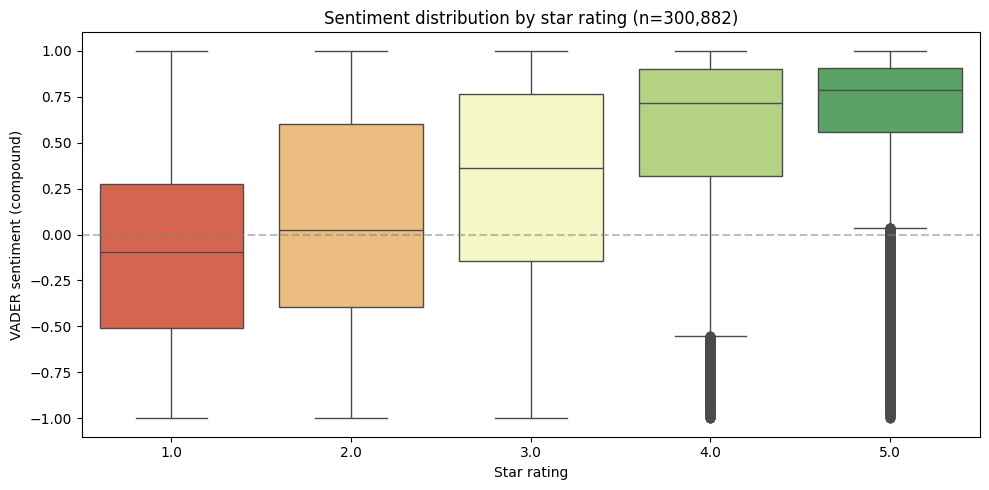

In [0]:
# Boxplot: sentiment distribution by rating
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_sample, x="rating", y="sent_compound",
            hue="rating", palette=sns.color_palette("RdYlGn", n_colors=5),
            ax=ax, legend=False)

# Horizontal reference line at sent_compound = 0 (neutral)
ax.axhline(0, color="grey", linestyle="--", alpha=0.5)

ax.set_xlabel("Star rating")
ax.set_ylabel("VADER sentiment (compound)")
ax.set_title("Sentiment distribution by star rating (n=300,882)")
plt.tight_layout()
plt.show()

In [0]:
# CASE 1: 1-star reviews scored as STRONGLY POSITIVE by VADER (>+0.5)
case_1pos = df_sample[
    (df_sample["rating"] == 1.0) & (df_sample["sent_compound"] > 0.5)
].sort_values("sent_compound", ascending=False)

# CASE 2: 5-star reviews scored as STRONGLY NEGATIVE by VADER (<-0.5)
case_5neg = df_sample[
    (df_sample["rating"] == 5.0) & (df_sample["sent_compound"] < -0.5)
].sort_values("sent_compound", ascending=True)

# ---------------- CASE 1 -----------------
print("=" * 75)
print("CASE 1 — 1-star reviews scored as strongly POSITIVE by VADER (>+0.5)")
print(f"Found: {len(case_1pos):,} cases out of {(df_sample['rating']==1.0).sum():,} one-star reviews")
print("=" * 75)
for _, row in case_1pos.head(5).iterrows():
    text = row['text'][:350] + ("..." if len(row['text']) > 350 else "")
    print(f"\nsent_compound = {row['sent_compound']:+.4f}  |  title: {row['title']}")
    print(f"text: {text}")
    print("-" * 75)

# ---------------- CASE 2 -----------------
print("\n\n" + "=" * 75)
print("CASE 2 — 5-star reviews scored as strongly NEGATIVE by VADER (<-0.5)")
print(f"Found: {len(case_5neg):,} cases out of {(df_sample['rating']==5.0).sum():,} five-star reviews")
print("=" * 75)
for _, row in case_5neg.head(5).iterrows():
    text = row['text'][:350] + ("..." if len(row['text']) > 350 else "")
    print(f"\nsent_compound = {row['sent_compound']:+.4f}  |  title: {row['title']}")
    print(f"text: {text}")
    print("-" * 75)

CASE 1 — 1-star reviews scored as strongly POSITIVE by VADER (>+0.5)
Found: 7,721 cases out of 50,588 one-star reviews

sent_compound = +0.9997  |  title: DO. NOT. BUY. Not right now, at least. Here's My Take, As to why.
text: [[VIDEOID:e453d1567c383601fb53dd966395450]] First off, the original review was 2 stars, I'm changing this to one, purely because of the fact that it wasn't what's advertised, on top of the fact more people will see this.<br />Now, I'm not sure what I should say here. I'm torn at the moment. I bet you're asking, why? I'll start from the beginning.  ...
---------------------------------------------------------------------------

sent_compound = +0.9995  |  title: OK controller. Motion controls do not work on PC. Edit: Left joystick broke.
text: Edit: No joke, only a few hours after writing this review my left joystick has started bugging out. When I hold forward, the stick seems to sometimes think I'm only pressing it about 90%-ish the way forward, making movement 

## **Modelling : predict customer satisfaction**

In [0]:
# Step 1 — Build binary label and split into train/test
from sklearn.model_selection import train_test_split

# Drop 3-star (ambiguous) and build binary label
df_binary = df_sample[df_sample["rating"] != 3.0].copy()
df_binary["satisfaction"] = (df_binary["rating"] >= 4).astype(int)
# Labels:  0 = unsatisfied  (rating 1 or 2)
#          1 = satisfied    (rating 4 or 5)
# 3-star reviews are EXCLUDED as ambiguous neutral (Pang & Lee, 2002)

print(f"Binary dataset size: {len(df_binary):,} (was {len(df_sample):,})")
print(f"3-star reviews dropped: {(df_sample['rating']==3.0).sum():,}\n")

X = df_binary["text"]
y = df_binary["satisfaction"]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Train: {len(X_train_b):,}  |  Test: {len(X_test_b):,}\n")
print(f"Class balance:")
print(f"  Train unsatisfied: {(y_train_b==0).sum():>7,}  ({(y_train_b==0).mean()*100:5.2f}%)")
print(f"  Train satisfied:   {(y_train_b==1).sum():>7,}  ({(y_train_b==1).mean()*100:5.2f}%)")
print(f"  Test  unsatisfied: {(y_test_b==0).sum():>7,}  ({(y_test_b==0).mean()*100:5.2f}%)")
print(f"  Test  satisfied:   {(y_test_b==1).sum():>7,}  ({(y_test_b==1).mean()*100:5.2f}%)")

Binary dataset size: 278,431 (was 300,882)
3-star reviews dropped: 22,451

Train: 222,744  |  Test: 55,687

Class balance:
  Train unsatisfied:  56,164  (25.21%)
  Train satisfied:   166,580  (74.79%)
  Test  unsatisfied:  14,041  (25.21%)
  Test  satisfied:    41,646  (74.79%)


In [0]:
# step 2: data preprocessing
import re

def clean_text(text):
    """Clean review text for TF-IDF vectorisation."""
    if not isinstance(text, str):
        return ""
    # Remove HTML tags (Amazon reviews often have <br />)
    text = re.sub(r"<[^>]+>", " ", text)
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    # Collapse extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Cleaning text...")
X_train_b_clean = X_train_b.apply(clean_text)
X_test_b_clean  = X_test_b.apply(clean_text)


Cleaning text...


In [0]:
# step 3: feature engineering

from sklearn.feature_extraction.text import TfidfVectorizer

print("Fitting TF-IDF (only on training set)...")
vectorizer_b = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=20_000,
    ngram_range=(1, 2),
    min_df=5, max_df=0.95,
    sublinear_tf=True,
)
X_train_b_tfidf = vectorizer_b.fit_transform(X_train_b_clean)
X_test_b_tfidf  = vectorizer_b.transform(X_test_b_clean)

print(f"\nX_train_b_tfidf shape: {X_train_b_tfidf.shape}")
print(f"X_test_b_tfidf  shape: {X_test_b_tfidf.shape}")
print(f"Vocabulary size: {len(vectorizer_b.vocabulary_):,}")

Fitting TF-IDF (only on training set)...

X_train_b_tfidf shape: (222744, 20000)
X_test_b_tfidf  shape: (55687, 20000)
Vocabulary size: 20,000


In [0]:
# balancing the dataset and training ML models
import time
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

binary_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, n_jobs=-1,
        class_weight="balanced"
    ),
    "Multinomial Naive Bayes": MultinomialNB(fit_prior=False),
    "Linear SVM": LinearSVC(
        random_state=42, max_iter=2000,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, n_jobs=-1, random_state=42,
        class_weight="balanced"
    ),
}

trained_binary_models = {}

for name, model in binary_models.items():
    print(f"Training {name}...")
    start = time.time()
    model.fit(X_train_b_tfidf, y_train_b)
    elapsed = time.time() - start
    trained_binary_models[name] = model
    print(f"  ✓ Done in {elapsed:.1f}s\n")

print(f"trained_binary_models has {len(trained_binary_models)} models ready.")

Training Logistic Regression...
  ✓ Done in 1.7s

Training Multinomial Naive Bayes...
  ✓ Done in 0.1s

Training Linear SVM...
  ✓ Done in 9.4s

Training Random Forest...
  ✓ Done in 658.3s

trained_binary_models has 4 models ready.


In [0]:
# step 5: evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from scipy.special import softmax

binary_results = []
y_preds_b = {}

for name, model in trained_binary_models.items():
    y_pred = model.predict(X_test_b_tfidf)
    y_preds_b[name] = y_pred

    # Probabilities for AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_b_tfidf)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test_b_tfidf)
    else:
        y_proba = None

    # Headline metrics
    acc       = accuracy_score(y_test_b, y_pred)
    prec_macro = precision_score(y_test_b, y_pred, average="macro", zero_division=0)
    rec_macro  = recall_score(y_test_b, y_pred, average="macro", zero_division=0)
    f1_macro   = f1_score(y_test_b, y_pred, average="macro", zero_division=0)

    # AUC
    auc = roc_auc_score(y_test_b, y_proba) if y_proba is not None else float("nan")

    binary_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (macro)": prec_macro,
        "Recall (macro)": rec_macro,
        "F1 (macro)": f1_macro,
        "AUC": auc,
    })

binary_summary_df = pd.DataFrame(binary_results).set_index("Model").round(4)
display(binary_summary_df.reset_index())
      

Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),AUC
Logistic Regression,0.9109,0.8721,0.9084,0.8876,0.969
Multinomial Naive Bayes,0.8838,0.8384,0.8862,0.8567,0.9551
Linear SVM,0.9095,0.8713,0.9025,0.885,0.9666
Random Forest,0.9022,0.8827,0.8506,0.8649,0.9527
